Load + Proper Missing Value Imputation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

plt.style.use('default')

# Load data
df = pd.read_csv("Global_Pollution_Analysis.csv")
print("Original shape:", df.shape)
print("Missing values per column:")
print(df.isnull().sum())


Original shape: (200, 13)
Missing values per column:
Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64


Impute instead of drop

In [3]:
df_imputed = df.copy()

# Numeric columns: mean by default, median specifically for pollution indices
num_cols = df_imputed.select_dtypes(include=[np.number]).columns

for col in num_cols:
    if col in ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']:
        df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())
    else:
        df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mean())

# Categorical (Country): forward fill then mode
df_imputed['Country'] = df_imputed['Country'].fillna(method='ffill')
df_imputed['Country'] = df_imputed['Country'].fillna(df_imputed['Country'].mode()[0])

print("Shape after imputation:", df_imputed.shape)
print("Remaining missing values:", df_imputed.isnull().sum().sum())


Shape after imputation: (200, 13)
Remaining missing values: 0


/tmp/ipython-input-288/3800482535.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_imputed['Country'] = df_imputed['Country'].fillna(method='ffill')


Scale Pollution Indices Separately (Phase 1 requirement)

In [4]:
df_eda = df_imputed.copy()

pollution_cols = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
pollution_scaler = MinMaxScaler()
df_eda[[c + '_Scaled' for c in pollution_cols]] = pollution_scaler.fit_transform(df_eda[pollution_cols])

df_eda[[c for c in df_eda.columns if 'Scaled' in c]].head()


,Air_Pollution_Index_Scaled,Water_Pollution_Index_Scaled,Soil_Pollution_Index_Scaled
0,0.898042,0.553778,0.295481
1,0.147062,0.173673,0.768178
2,0.166727,0.310542,0.800768
3,0.929982,0.214222,0.596973
4,0.520331,0.573161,0.799537


Feature Engineering: Pollution_Index + Energy per Capita + Severity

In [6]:
df_model = df_eda.copy()

# Composite pollution index
df_model['Pollution_Index'] = (
    df_model['Air_Pollution_Index'] +
    df_model['Water_Pollution_Index'] +
    df_model['Soil_Pollution_Index']
) / 3

# Energy Consumption per Capita (already per capita; keep as is, just rename if needed)
df_model['Energy_Consumption_per_Capita'] = df_model['Energy_Consumption_Per_Capita (in MWh)']

# Pollution severity (Low/Medium/High tertiles)
df_model['Pollution_Severity'] = pd.qcut(
    df_model['Pollution_Index'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

le_severity = LabelEncoder()
df_model['Pollution_Severity_Encoded'] = le_severity.fit_transform(df_model['Pollution_Severity'])

# Encode Country
le_country = LabelEncoder()
df_model['Country_Encoded'] = le_country.fit_transform(df_model['Country'])


Year-based Trends and Time-series Visuals

Global yearly trends

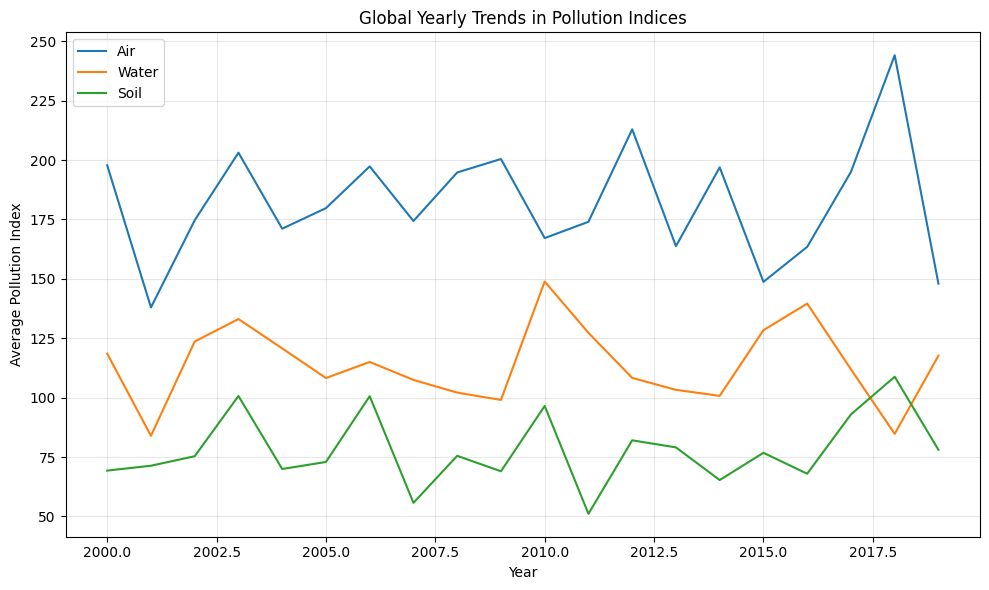

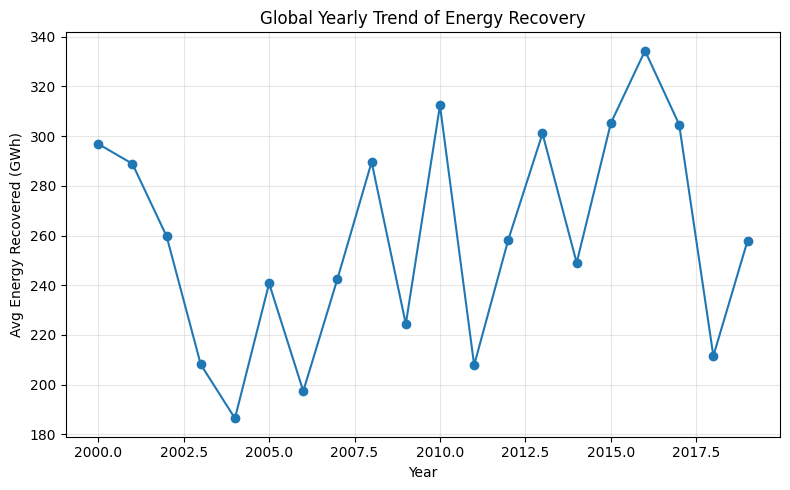

In [7]:
year_group = df_eda.groupby('Year').agg({
    'Air_Pollution_Index': 'mean',
    'Water_Pollution_Index': 'mean',
    'Soil_Pollution_Index': 'mean',
    'Energy_Recovered (in GWh)': 'mean'
}).reset_index()

plt.figure(figsize=(10,6))
plt.plot(year_group['Year'], year_group['Air_Pollution_Index'], label='Air')
plt.plot(year_group['Year'], year_group['Water_Pollution_Index'], label='Water')
plt.plot(year_group['Year'], year_group['Soil_Pollution_Index'], label='Soil')
plt.xlabel('Year')
plt.ylabel('Average Pollution Index')
plt.title('Global Yearly Trends in Pollution Indices')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(year_group['Year'], year_group['Energy_Recovered (in GWh)'], marker='o')
plt.xlabel('Year')
plt.ylabel('Avg Energy Recovered (GWh)')
plt.title('Global Yearly Trend of Energy Recovery')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Per-country time-series (pollution over time)

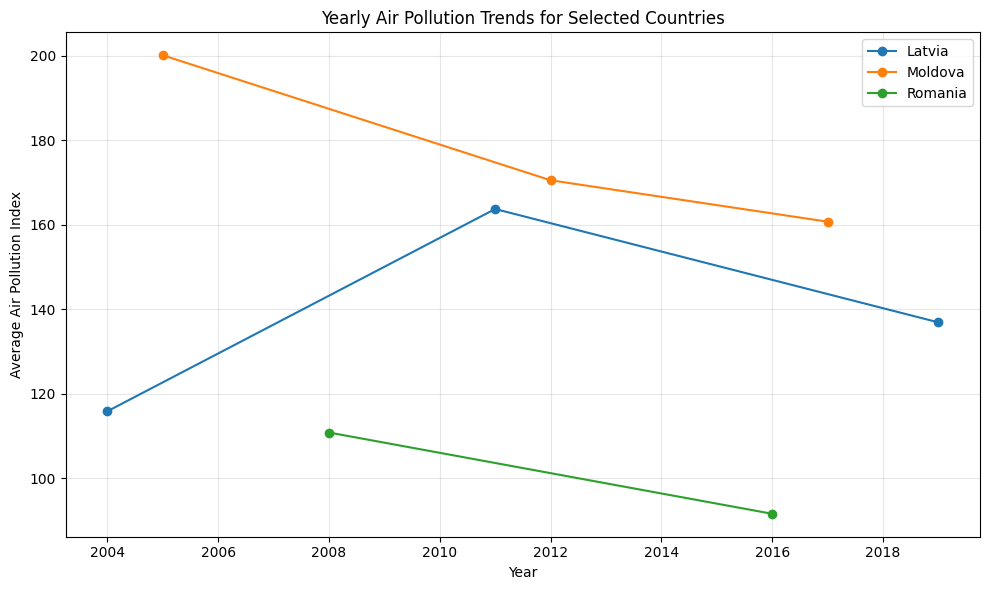

In [8]:
top_countries = df_eda['Country'].value_counts().head(3).index.tolist()

plt.figure(figsize=(10,6))
for c in top_countries:
    sub = df_eda[df_eda['Country'] == c].groupby('Year')['Air_Pollution_Index'].mean().reset_index()
    plt.plot(sub['Year'], sub['Air_Pollution_Index'], marker='o', label=c)

plt.xlabel('Year')
plt.ylabel('Average Air Pollution Index')
plt.title('Yearly Air Pollution Trends for Selected Countries')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Modelling: Regression (Energy_Recovered)

Features, split, scaling

In [9]:
features_reg = [
    'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index',
    'Industrial_Waste (in tons)', 'CO2_Emissions (in MT)',
    'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
    'Energy_Consumption_per_Capita',
    'Population (in millions)', 'GDP_Per_Capita (in USD)',
    'Country_Encoded', 'Pollution_Index'
]

X_reg = df_model[features_reg]
y_reg = df_model['Energy_Recovered (in GWh)']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)


Linear + Ridge Regression with metrics

In [10]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_reg = lin_reg.predict(X_test_reg_scaled)

mse_reg = mean_squared_error(y_test_reg, y_pred_reg)
rmse_reg = np.sqrt(mse_reg)
mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)
r2_reg = r2_score(y_test_reg, y_pred_reg)

# Ridge Regression
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_ridge = ridge_reg.predict(X_test_reg_scaled)

mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test_reg, y_pred_ridge)
r2_ridge = r2_score(y_test_reg, y_pred_ridge)

print("=== REGRESSION METRICS ===")
print(f"Linear Regression: R²={r2_reg:.3f}, RMSE={rmse_reg:.2f}, MAE={mae_reg:.2f}")
print(f"Ridge Regression:  R²={r2_ridge:.3f}, RMSE={rmse_ridge:.2f}, MAE={mae_ridge:.2f}")


=== REGRESSION METRICS ===
Linear Regression: R²=-0.116, RMSE=164.26, MAE=146.29
Ridge Regression:  R²=-0.115, RMSE=164.19, MAE=146.25


Modelling: Logistic Regression (Pollution Severity)

In [11]:
features_cls = features_reg + ['Energy_Recovered (in GWh)']

X_cls = df_model[features_cls]
y_cls = df_model['Pollution_Severity_Encoded']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

log_reg = LogisticRegression(max_iter=1000, multi_class='multinomial')
log_reg.fit(X_train_cls_scaled, y_train_cls)
y_pred_cls = log_reg.predict(X_test_cls_scaled)

acc_cls = accuracy_score(y_test_cls, y_pred_cls)
prec_cls = precision_score(y_test_cls, y_pred_cls, average='weighted')
rec_cls = recall_score(y_test_cls, y_pred_cls, average='weighted')
f1_cls = f1_score(y_test_cls, y_pred_cls, average='weighted')

cm = confusion_matrix(y_test_cls, y_pred_cls)
print("Confusion matrix:\n", cm)

print("\n=== CLASSIFICATION METRICS ===")
print(f"Logistic Regression: Acc={acc_cls:.3f}, Prec={prec_cls:.3f}, Rec={rec_cls:.3f}, F1={f1_cls:.3f}")


Confusion matrix:
 [[14  0  0]
 [ 0 13  0]
 [ 2  0 11]]

=== CLASSIFICATION METRICS ===
Logistic Regression: Acc=0.950, Prec=0.956, Rec=0.950, F1=0.950


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Metric Table for Report

In [12]:
print("\n=== MODEL SUMMARY TABLE ===")
print(f"Linear Regression      | R²={r2_reg:.3f} | RMSE={rmse_reg:.2f} | MAE={mae_reg:.2f}")
print(f"Ridge Regression       | R²={r2_ridge:.3f} | RMSE={rmse_ridge:.2f} | MAE={mae_ridge:.2f}")
print(f"Logistic Regression    | Acc={acc_cls:.3f} | Prec={prec_cls:.3f} | Rec={rec_cls:.3f} | F1={f1_cls:.3f}")



=== MODEL SUMMARY TABLE ===
Linear Regression      | R²=-0.116 | RMSE=164.26 | MAE=146.29
Ridge Regression       | R²=-0.115 | RMSE=164.19 | MAE=146.25
Logistic Regression    | Acc=0.950 | Prec=0.956 | Rec=0.950 | F1=0.950


Country-specific recommendations using outputs

In [13]:
# Average pollution and energy recovery per country
country_stats = df_model.groupby('Country_Encoded').agg({
    'Pollution_Index': 'mean',
    'Energy_Recovered (in GWh)': 'mean'
}).reset_index()

# Map back to names
inv_country = dict(zip(df_model['Country_Encoded'], df_model['Country']))
country_stats['Country'] = country_stats['Country_Encoded'].map(inv_country)

high_pollution = country_stats.sort_values('Pollution_Index', ascending=False).head(5)
high_recovery = country_stats.sort_values('Energy_Recovered (in GWh)', ascending=False).head(5)

print("Top 5 High Pollution Countries:")
print(high_pollution[['Country', 'Pollution_Index']])

print("\nTop 5 Energy Recovery Countries:")
print(high_recovery[['Country', 'Energy_Recovered (in GWh)']])


Top 5 High Pollution Countries:
                      Country  Pollution_Index
138          Saint Barthelemy       187.036667
20                    Bolivia       181.496667
31   Central African Republic       177.016667
35           Christmas Island       175.950000
129          Papua New Guinea       175.660000

Top 5 Energy Recovery Countries:
                      Country  Energy_Recovered (in GWh)
31   Central African Republic                     499.98
147                 Singapore                     498.04
156                 Swaziland                     495.28
54                    Estonia                     493.12
72                      Haiti                     492.08
